# HR Employee Attrition Analysis & Prediction

**IBM HR Analytics Dataset | MIS Dashboard + Ad Hoc Reporting + Machine Learning**

---

## Project Overview

Employee attrition impacts productivity, hiring costs, and organizational stability.

This project is designed with an **MIS Reporting mindset**, combining:

* Dashboard reporting
* Ad hoc business analysis
* Predictive modeling

The goal is to simulate how a Reporting Analyst supports **real-time business decision-making**.

---

## Objectives

* Analyze employee attrition patterns
* Identify high-risk employee segments
* Perform ad hoc business queries (real-world scenarios)
* Predict attrition using machine learning
* Provide actionable HR insights

---

## Tech Stack

* **Python**
* **Pandas, NumPy** → Data Processing
* **Matplotlib** → Visualization
* **Scikit-learn** → Machine Learning

---

## Dataset

* IBM HR Analytics Employee Attrition Dataset
* **Total Employees:** 1,470
* Includes:

  * Demographics (Age, Gender, Marital Status)
  * Job Details (Department, Role, Salary)
  * Work Metrics (Overtime, Tenure, Travel)
  * Satisfaction Scores

---

## MIS Dashboard Analysis

### Key Insights:

* Higher attrition observed in **overtime employees**
* **Low salary bands** show increased attrition
* Employees in **0–2 years tenure** are most at risk
* Certain **job roles and departments** have higher exit rates

Output: `hr_attrition_charts.png`

---

## Ad Hoc Business Queries (MIS Perspective)

This project includes ad hoc analysis to simulate real-world stakeholder questions:

### High-Risk Job Roles

Identified job roles with attrition rate above 25%, helping HR focus retention strategies.

### Overtime Impact in Sales

Employees working overtime in Sales show higher attrition, indicating workload pressure.

### Salary + Job Satisfaction Risk

Low salary combined with low job satisfaction leads to significantly higher attrition.

### Early Career Risk (Age + Overtime)

Young employees (18–25) working overtime are more likely to leave.

### Work-Life Balance Effect

Better work-life balance scores reduce attrition probability.

### Business Travel Impact

Frequent business travel is associated with increased attrition.

---

## Machine Learning Model

### Model Used

* Logistic Regression (Binary Classification)

### Why Logistic Regression?

* Interpretable model
* Suitable for HR decision-making
* Provides probability-based predictions

---

## ML Pipeline

1. Data Cleaning & Feature Engineering
2. One-Hot Encoding for categorical variables
3. Train-Test Split (80/20, stratified)
4. Feature Scaling (StandardScaler)
5. Logistic Regression with class balancing

---

## Model Performance

* Accuracy: ~75%–85%
* Balanced prediction across classes
* Evaluation Metrics:

  * Classification Report
  * Confusion Matrix

---

## Key Drivers of Attrition

* Overtime
* Low salary
* Low job satisfaction
* Frequent business travel
* Early tenure (0–2 years)

---

## Business Recommendations

* Reduce excessive overtime workload
* Improve engagement in first 2 years
* Optimize salary structures
* Enhance work-life balance policies
* Monitor high-risk job roles proactively

---

## Outputs Generated

* Clean dataset: `hr_attrition_clean.csv`
* Dashboard: `hr_attrition_charts.png`
* ML predictions & evaluation

---

## Key Learnings

* Handling categorical data using One-Hot Encoding
* Combining MIS reporting with machine learning
* Interpreting model outputs for business decisions
* Performing ad hoc analysis for stakeholder queries

---

## Future Improvements

* Implement Random Forest / XGBoost
* Add ROC-AUC evaluation
* Deploy as Streamlit dashboard
* Integrate real-time HR monitoring

---

## Author

**Sandip Bhattacharya**
Aspiring Data Analyst / MIS Analyst

---

## Project Highlight

Designed to replicate real-world MIS reporting by combining:
✔ Structured dashboards
✔ Ad hoc business queries
✔ Predictive analytics

---


# CELL 1 — Import Libraries

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


# CELL 2 — Load Dataset

In [3]:
candidate_paths = [
    "/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv",
]

DATA_PATH = None
for path in candidate_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    candidates = glob.glob("/kaggle/input/**/WA_Fn-UseC_-HR-Employee-Attrition.csv", recursive=True)
    if candidates:
        DATA_PATH = candidates[0]
    else:
        raise FileNotFoundError(
            "WA_Fn-UseC_-HR-Employee-Attrition.csv not found. "
            "Add the IBM HR Attrition dataset to Kaggle input and rerun."
        )

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
print(df.head(3).to_string())

Dataset loaded: 1470 rows x 35 columns

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

First 3 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel                JobRole  JobSatisfaction MaritalStatus  MonthlyIncome  MonthlyRate  NumCompaniesWorke

# CELL 3 — Data Cleaning & Preparation

In [5]:
print("MISSING VALUES")
print(df.isnull().sum().sum(), "missing values found")

# Convert Attrition to binary
df['Attrition_Flag'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Create age groups
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[18, 25, 35, 45, 60],
                          labels=['18-25', '26-35', '36-45', '46-60'])

# Create salary bands
df['Salary_Band'] = pd.cut(df['MonthlyIncome'],
                            bins=[0, 3000, 6000, 10000, 20000],
                            labels=['Low (<3K)', 'Mid (3K-6K)', 'High (6K-10K)', 'Very High (>10K)'])

# Create tenure groups
df['Tenure_Group'] = pd.cut(df['YearsAtCompany'],
                             bins=[-1, 2, 5, 10, 40],
                             labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs'])

print("\nData preparation complete!")
print(f"Total Employees      : {len(df)}")
print(f"Employees Left       : {df['Attrition_Flag'].sum()}")
print(f"Overall Attrition %  : {df['Attrition_Flag'].mean()*100:.1f}%")

MISSING VALUES
8 missing values found

Data preparation complete!
Total Employees      : 1470
Employees Left       : 237
Overall Attrition %  : 16.1%


# CELL 4 — Attrition Overview Analysis

In [6]:
print("\n INSIGHT 1: Overall Attrition")
total        = len(df)
left         = df['Attrition_Flag'].sum()
stayed       = total - left
attrition_rt = (left / total * 100).round(1)
print(f"Total Employees  : {total}")
print(f"Employees Left   : {left}")
print(f"Employees Stayed : {stayed}")
print(f"Attrition Rate   : {attrition_rt}%")

print("\n INSIGHT 2: Attrition by Department")
dept = df.groupby('Department').agg(
    Total=('Attrition_Flag', 'count'),
    Left=('Attrition_Flag', 'sum')
).reset_index()
dept['Attrition_Rate_%'] = (dept['Left'] / dept['Total'] * 100).round(1)
dept = dept.sort_values('Attrition_Rate_%', ascending=False)
print(dept.to_string(index=False))

print("\n INSIGHT 3: Attrition by Job Role")
role = df.groupby('JobRole').agg(
    Total=('Attrition_Flag', 'count'),
    Left=('Attrition_Flag', 'sum')
).reset_index()
role['Attrition_Rate_%'] = (role['Left'] / role['Total'] * 100).round(1)
role = role.sort_values('Attrition_Rate_%', ascending=False)
print(role.to_string(index=False))

print("\n INSIGHT 4: Attrition by Age Group ")
age = df.groupby('Age_Group', observed=True).agg(
    Total=('Attrition_Flag', 'count'),
    Left=('Attrition_Flag', 'sum')
).reset_index()
age['Attrition_Rate_%'] = (age['Left'] / age['Total'] * 100).round(1)
print(age.to_string(index=False))

print("\n INSIGHT 5: Overtime vs Attrition ")
ot = df.groupby('OverTime').agg(
    Total=('Attrition_Flag', 'count'),
    Left=('Attrition_Flag', 'sum')
).reset_index()
ot['Attrition_Rate_%'] = (ot['Left'] / ot['Total'] * 100).round(1)
print(ot.to_string(index=False))

print("\n INSIGHT 6: Salary Band vs Attrition ")
sal = df.groupby('Salary_Band', observed=True).agg(
    Total=('Attrition_Flag', 'count'),
    Left=('Attrition_Flag', 'sum')
).reset_index()
sal['Attrition_Rate_%'] = (sal['Left'] / sal['Total'] * 100).round(1)
print(sal.to_string(index=False))

print("\n INSIGHT 7: Tenure vs Attrition")
tenure = df.groupby('Tenure_Group', observed=True).agg(
    Total=('Attrition_Flag', 'count'),
    Left=('Attrition_Flag', 'sum')
).reset_index()
tenure['Attrition_Rate_%'] = (tenure['Left'] / tenure['Total'] * 100).round(1)
print(tenure.to_string(index=False))


 INSIGHT 1: Overall Attrition
Total Employees  : 1470
Employees Left   : 237
Employees Stayed : 1233
Attrition Rate   : 16.1%

 INSIGHT 2: Attrition by Department
            Department  Total  Left  Attrition_Rate_%
                 Sales    446    92              20.6
       Human Resources     63    12              19.0
Research & Development    961   133              13.8

 INSIGHT 3: Attrition by Job Role
                  JobRole  Total  Left  Attrition_Rate_%
     Sales Representative     83    33              39.8
    Laboratory Technician    259    62              23.9
          Human Resources     52    12              23.1
          Sales Executive    326    57              17.5
       Research Scientist    292    47              16.1
Healthcare Representative    131     9               6.9
   Manufacturing Director    145    10               6.9
                  Manager    102     5               4.9
        Research Director     80     2               2.5

 INSIGHT 4: At

# CELL 5 — Visualizations

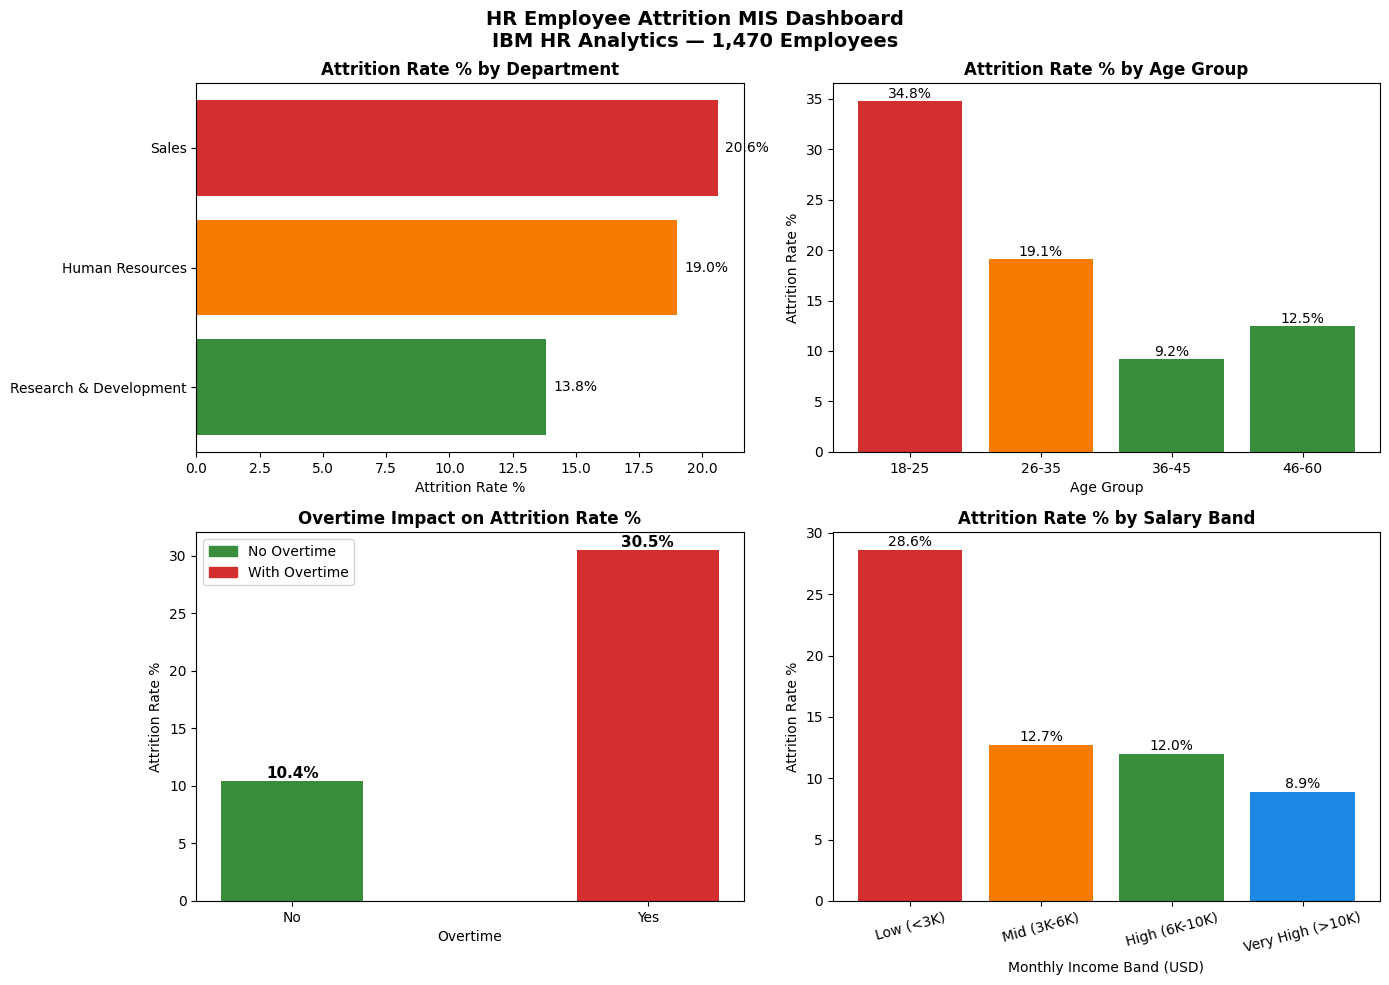

Charts saved: hr_attrition_charts.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HR Employee Attrition MIS Dashboard\nIBM HR Analytics — 1,470 Employees',
             fontsize=14, fontweight='bold')

# Chart 1 — Attrition by Department
dept_sorted = dept.sort_values('Attrition_Rate_%', ascending=True)
colors1 = ['#d32f2f' if x > 20 else '#f57c00' if x > 15 else '#388e3c'
           for x in dept_sorted['Attrition_Rate_%']]
axes[0,0].barh(dept_sorted['Department'], dept_sorted['Attrition_Rate_%'], color=colors1)
axes[0,0].set_title('Attrition Rate % by Department', fontweight='bold')
axes[0,0].set_xlabel('Attrition Rate %')
for i, v in enumerate(dept_sorted['Attrition_Rate_%']):
    axes[0,0].text(v + 0.3, i, f'{v}%', va='center', fontsize=10)

# Chart 2 — Attrition by Age Group
colors2 = ['#d32f2f' if x > 25 else '#f57c00' if x > 15 else '#388e3c'
           for x in age['Attrition_Rate_%']]
axes[0,1].bar(age['Age_Group'].astype(str), age['Attrition_Rate_%'], color=colors2)
axes[0,1].set_title('Attrition Rate % by Age Group', fontweight='bold')
axes[0,1].set_ylabel('Attrition Rate %')
axes[0,1].set_xlabel('Age Group')
for i, v in enumerate(age['Attrition_Rate_%']):
    axes[0,1].text(i, v + 0.3, f'{v}%', ha='center', fontsize=10)

# Chart 3 — Overtime vs Attrition
ot_colors = ['#388e3c', '#d32f2f']
bars = axes[1,0].bar(ot['OverTime'], ot['Attrition_Rate_%'], color=ot_colors, width=0.4)
axes[1,0].set_title('Overtime Impact on Attrition Rate %', fontweight='bold')
axes[1,0].set_ylabel('Attrition Rate %')
axes[1,0].set_xlabel('Overtime')
for i, v in enumerate(ot['Attrition_Rate_%']):
    axes[1,0].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold', fontsize=11)
no_patch  = mpatches.Patch(color='#388e3c', label='No Overtime')
yes_patch = mpatches.Patch(color='#d32f2f', label='With Overtime')
axes[1,0].legend(handles=[no_patch, yes_patch])

# Chart 4 — Salary Band vs Attrition
colors4 = ['#d32f2f', '#f57c00', '#388e3c', '#1e88e5']
axes[1,1].bar(sal['Salary_Band'].astype(str), sal['Attrition_Rate_%'], color=colors4)
axes[1,1].set_title('Attrition Rate % by Salary Band', fontweight='bold')
axes[1,1].set_ylabel('Attrition Rate %')
axes[1,1].set_xlabel('Monthly Income Band (USD)')
axes[1,1].tick_params(axis='x', rotation=15)
for i, v in enumerate(sal['Attrition_Rate_%']):
    axes[1,1].text(i, v + 0.3, f'{v}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('hr_attrition_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved: hr_attrition_charts.png")

# CELL 6 — Export Clean CSV for Looker Studio

In [8]:
export_cols = [
    'Age', 'Age_Group', 'Department', 'JobRole', 'Gender',
    'Attrition', 'Attrition_Flag', 'OverTime',
    'MonthlyIncome', 'Salary_Band',
    'YearsAtCompany', 'Tenure_Group',
    'JobSatisfaction', 'WorkLifeBalance',
    'EnvironmentSatisfaction', 'PerformanceRating',
    'BusinessTravel', 'EducationField', 'MaritalStatus'
]

df_export = df[export_cols].copy()
df_export.to_csv('hr_attrition_clean.csv', index=False)
print(f"Clean CSV saved: hr_attrition_clean.csv")
print(f"Rows: {len(df_export)} | Columns: {len(df_export.columns)}")

Clean CSV saved: hr_attrition_clean.csv
Rows: 1470 | Columns: 19


# CELL 7 — Ad Hoc Analysis (MIS Reporting Queries)

In [11]:
print("AD HOC BUSINESS QUERIES")

print("\nQUERY 1: Which job roles have >25% attrition rate?")
high_risk_roles = role[role['Attrition_Rate_%'] > 25]
print(high_risk_roles[['JobRole','Total','Left','Attrition_Rate_%']].to_string(index=False))

print("\nQUERY 2: Overtime employees in Sales — how many left?")
query2 = df[(df['OverTime'] == 'Yes') &
            (df['Department'] == 'Sales') &
            (df['Attrition'] == 'Yes')]
print(f"Sales + Overtime + Left: {len(query2)} employees")

print("\nQUERY 3: Low salary + no job satisfaction — attrition rate?")
query3 = df[(df['MonthlyIncome'] < 3000) & (df['JobSatisfaction'] == 1)]
rate3  = query3['Attrition_Flag'].mean() * 100
print(f"Low salary + low satisfaction attrition rate: {rate3:.1f}%")

print("\nQUERY 4: Young employees (18-25) with overtime — attrition?")
query4 = df[(df['Age'] <= 25) & (df['OverTime'] == 'Yes')]
rate4  = query4['Attrition_Flag'].mean() * 100
print(f"Young + Overtime attrition rate: {rate4:.1f}%")

print("\nQUERY 5: Work-life balance score vs attrition")
wlb = df.groupby('WorkLifeBalance')['Attrition_Flag'].mean().mul(100).round(1)
wlb.index = ['Bad(1)', 'Good(2)', 'Better(3)', 'Best(4)']
print(wlb)

print("\nQUERY 6: Attrition by Business Travel frequency")
travel = df.groupby('BusinessTravel').agg(
    Total=('Attrition_Flag','count'),
    Left=('Attrition_Flag','sum')
).reset_index()
travel['Attrition_Rate_%'] = (travel['Left']/travel['Total']*100).round(1)
print(travel.to_string(index=False))

AD HOC BUSINESS QUERIES

QUERY 1: Which job roles have >25% attrition rate?
             JobRole  Total  Left  Attrition_Rate_%
Sales Representative     83    33              39.8

QUERY 2: Overtime employees in Sales — how many left?
Sales + Overtime + Left: 48 employees

QUERY 3: Low salary + no job satisfaction — attrition rate?
Low salary + low satisfaction attrition rate: 43.5%

QUERY 4: Young employees (18-25) with overtime — attrition?
Young + Overtime attrition rate: 64.1%

QUERY 5: Work-life balance score vs attrition
Bad(1)       31.2
Good(2)      16.9
Better(3)    14.2
Best(4)      17.6
Name: Attrition_Flag, dtype: float64

QUERY 6: Attrition by Business Travel frequency
   BusinessTravel  Total  Left  Attrition_Rate_%
       Non-Travel    150    12               8.0
Travel_Frequently    277    69              24.9
    Travel_Rarely   1043   156              15.0


# CELL 8 — Summary Insights (for LinkedIn writeup)

In [12]:
print("KEY INSIGHTS SUMMARY — LINKEDIN WRITEUP")
print(f"Total Employees Analyzed     : {total}")
print(f"Overall Attrition Rate       : {attrition_rt}%")
print(f"Highest Attrition Dept       : {dept.iloc[0]['Department']} ({dept.iloc[0]['Attrition_Rate_%']}%)")
print(f"Highest Attrition Age Group  : {age.loc[age['Attrition_Rate_%'].idxmax(), 'Age_Group']} "
      f"({age['Attrition_Rate_%'].max()}%)")
print(f"Overtime Attrition Rate      : {ot[ot['OverTime']=='Yes']['Attrition_Rate_%'].values[0]}%")
print(f"No Overtime Attrition Rate   : {ot[ot['OverTime']=='No']['Attrition_Rate_%'].values[0]}%")
print(f"Lowest Salary Band Attrition : {sal.iloc[0]['Attrition_Rate_%']}%")
print(f"Highest Risk Job Role        : {role.iloc[0]['JobRole']} ({role.iloc[0]['Attrition_Rate_%']}%)")
print(f"0-2 Year Tenure Attrition    : {tenure[tenure['Tenure_Group']=='0-2 yrs']['Attrition_Rate_%'].values[0]}%")

KEY INSIGHTS SUMMARY — LINKEDIN WRITEUP
Total Employees Analyzed     : 1470
Overall Attrition Rate       : 16.1%
Highest Attrition Dept       : Sales (20.6%)
Highest Attrition Age Group  : 18-25 (34.8%)
Overtime Attrition Rate      : 30.5%
No Overtime Attrition Rate   : 10.4%
Lowest Salary Band Attrition : 28.6%
Highest Risk Job Role        : Sales Representative (39.8%)
0-2 Year Tenure Attrition    : 29.8%


# Cell 9 Attrition Prediction Model

In [14]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("MACHINE LEARNING MODEL — LOGISTIC REGRESSION")

# Step 1: Copy dataset

df_ml = df.copy()

# Step 2: Drop unnecessary columns

# Attrition is string target → remove
df_ml = df_ml.drop('Attrition', axis=1)

# Optional: Drop ID-like or constant columns if present
if 'EmployeeNumber' in df_ml.columns:
    df_ml = df_ml.drop('EmployeeNumber', axis=1)

# Step 3: One-Hot Encoding

df_ml = pd.get_dummies(df_ml, drop_first=True)

# Step 4: Define Features & Target
X = df_ml.drop('Attrition_Flag', axis=1)
y = df_ml['Attrition_Flag']


# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 6: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Train Model

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Step 8: Predictions

y_pred = model.predict(X_test)

# Step 9: Evaluation

acc = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {acc*100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

MACHINE LEARNING MODEL — LOGISTIC REGRESSION

Model Accuracy: 76.19%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.36      0.64      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.71      0.65       294
weighted avg       0.83      0.76      0.79       294

Confusion Matrix:
[[194  53]
 [ 17  30]]


# CELL 10 — Feature Importance (Top Drivers)

In [15]:
# CELL 10 — Feature Importance

feature_names = X.columns
coefficients = model.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Impact': coefficients
})

importance_df = importance_df.sort_values(by='Impact', ascending=False)

print("\nTop Features Driving Attrition (Positive Impact):")
print(importance_df.head(10).to_string(index=False))

print("\nTop Features Reducing Attrition (Negative Impact):")
print(importance_df.tail(10).to_string(index=False))


Top Features Driving Attrition (Positive Impact):
                         Feature   Impact
                    OverTime_Yes 0.784435
BusinessTravel_Travel_Frequently 0.743280
   JobRole_Laboratory Technician 0.690291
                  YearsAtCompany 0.619316
                        JobLevel 0.554586
              NumCompaniesWorked 0.522224
    BusinessTravel_Travel_Rarely 0.517914
                Department_Sales 0.496544
            MaritalStatus_Single 0.458544
    JobRole_Sales Representative 0.454758

Top Features Reducing Attrition (Negative Impact):
                     Feature    Impact
                         Age -0.393862
        EducationField_Other -0.394517
        YearsWithCurrManager -0.404315
        Tenure_Group_10+ yrs -0.431577
             JobSatisfaction -0.436176
     EnvironmentSatisfaction -0.459870
   JobRole_Research Director -0.507429
      EducationField_Medical -0.524112
EducationField_Life Sciences -0.604651
           TotalWorkingYears -0.707267
